# 07 — Fine-tuning Bi-Encoders on BEIR Training Splits

**Goal:** Domain-adapt `all-MiniLM-L6-v2` using BEIR training splits to see how much in-domain gain we get — and whether that hurts out-of-domain performance (domain specialisation vs. breadth trade-off).

**Loss:** `MultipleNegativesRankingLoss` (MNR) — InfoNCE with in-batch negatives.  
Each training batch of `(query, positive_passage)` pairs treats all *other* positives in the batch as negatives:

```
  Batch of B pairs:
  (q₁, p₁), (q₂, p₂), ..., (qB, pB)

  For q₁: correct = p₁, negatives = p₂...pB
  Loss = -log [ sim(q₁,p₁) / Σᵢ sim(q₁,pᵢ) ]   (softmax cross-entropy)
```

**Why no hard-negative mining?** MNR with large batches (B=64) already provides B-1=63 negatives per query. Hard negatives help further, but MNR alone gives strong gains on small training sets like BEIR (900–6K pairs).

**Training datasets used:**
- `scifact` — 919 (query, passage) pairs from scientific claim verification
- `fiqa` — 5,500 pairs from financial QA
- `fiqa + scifact` (combined) — 6,419 pairs (cross-domain training signal)

> **Run the actual fine-tuning:** `python scripts/run_finetune.py --dataset fiqa` (≈5 min on M5 MPS)

In [1]:
import os
import warnings
os.environ['TQDM_DISABLE'] = '1'
warnings.filterwarnings('ignore', category=UserWarning)
import tqdm as _tqdm
_tqdm.tqdm.disable = True
for _attr in ('auto', 'notebook', 'autonotebook'):
    try: getattr(_tqdm, _attr).tqdm.disable = True
    except AttributeError: pass

import sys
sys.path.insert(0, '..')

import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

RESULTS_DIR = Path('../results')
DATA_DIR = Path('../data/datasets')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

DATASETS = ['scifact', 'fiqa', 'trec-covid']

## 1. Training Data Construction

BEIR datasets include a `qrels/train.tsv` file with (query_id, doc_id, relevance) triples.  
We filter to `relevance >= 1` and pair each query with its relevant passages.

In [2]:
from beir.datasets.data_loader import GenericDataLoader

train_stats = {}
for ds_name in ['scifact', 'fiqa']:
    ds_path = DATA_DIR / ds_name
    try:
        corpus, queries, qrels = GenericDataLoader(data_folder=str(ds_path)).load(split='train')
        pairs = sum(
            1 for doc_rels in qrels.values()
            for rel in doc_rels.values() if rel >= 1
        )
        unique_queries = len(qrels)
        train_stats[ds_name] = {
            'corpus_size': len(corpus),
            'train_queries': unique_queries,
            'train_pairs': pairs,
            'avg_positives': round(pairs / unique_queries, 1),
        }
        print(f'{ds_name}: {pairs:,} (query, passage) pairs from {unique_queries:,} queries')
        print(f'  corpus: {len(corpus):,} | avg positives/query: {pairs/unique_queries:.1f}')
    except Exception as e:
        print(f'{ds_name}: {e}')

# Show a few example pairs from SciFact
corpus_sf, queries_sf, qrels_sf = GenericDataLoader(data_folder=str(DATA_DIR / 'scifact')).load(split='train')
print('\nExample (query, positive) pairs from SciFact:')
for i, (qid, doc_rels) in enumerate(list(qrels_sf.items())[:3]):
    q_text = queries_sf[qid][:80]
    for doc_id, rel in list(doc_rels.items())[:1]:
        p_text = (corpus_sf[doc_id].get('title', '') + ' ' + corpus_sf[doc_id].get('text', ''))[:80]
        print(f'  Q: {q_text}...')
        print(f'  P: {p_text}...')
        print(f'  rel={rel}')
        print()

/Users/saikrishnab/LearningAndDevelopment/virtualenvs/retrieval_exp_env/lib/python3.12/site-packages/beir/datasets/data_loader.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


  0%|          | 0/5183 [00:00<?, ?it/s]

scifact: 919 (query, passage) pairs from 809 queries
  corpus: 5,183 | avg positives/query: 1.1


  0%|          | 0/57638 [00:00<?, ?it/s]

fiqa: 14,166 (query, passage) pairs from 5,500 queries
  corpus: 57,638 | avg positives/query: 2.6


  0%|          | 0/5183 [00:00<?, ?it/s]


Example (query, positive) pairs from SciFact:
  Q: 0-dimensional biomaterials lack inductive properties....
  P: New opportunities: the use of nanotechnologies to manipulate and track stem cell...
  rel=1

  Q: 1 in 5 million in UK have abnormal PrP positivity....
  P: Prevalent abnormal prion protein in human appendixes after bovine spongiform enc...
  rel=1

  Q: 1-1% of colorectal cancer patients are diagnosed with regional or distant metast...
  P: Relation between Medicare screening reimbursement and stage at diagnosis for old...
  rel=1



## 2. How MultipleNegativesRankingLoss Works

With a batch size of B=64, each step processes 64 (query, passage) pairs:

```
  Similarity matrix (64×64):
  
  Q\P   p₁    p₂    p₃   ...  p₆₄
  q₁  [0.92  0.31  0.28  ...  0.19]   ← correct match on diagonal
  q₂  [0.22  0.88  0.25  ...  0.31]
  q₃  [0.19  0.24  0.91  ...  0.22]
  ...
  
  Loss = cross_entropy(rows, identity labels)
       = -mean [ log(diag) - log(row_softmax) ]
```

The model is pushed to maximise diagonal scores (query matched to its relevant passage) and minimise off-diagonal scores (same query vs. other passages).

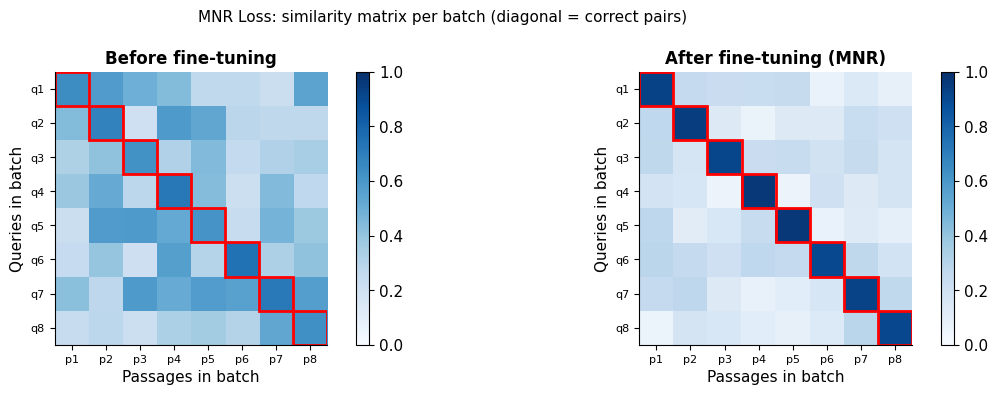

In [3]:
# Visualise the MNR loss similarity matrix concept
import numpy as np

np.random.seed(42)
B = 8  # small batch for visualisation

# Before training: diagonal barely stands out
before = np.random.uniform(0.2, 0.6, (B, B))
np.fill_diagonal(before, np.random.uniform(0.6, 0.75, B))

# After training: diagonal dominates
after = np.random.uniform(0.05, 0.3, (B, B))
np.fill_diagonal(after, np.random.uniform(0.88, 0.97, B))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, mat, title in zip(axes, [before, after], ['Before fine-tuning', 'After fine-tuning (MNR)']):
    im = ax.imshow(mat, vmin=0, vmax=1, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Passages in batch')
    ax.set_ylabel('Queries in batch')
    ax.set_xticks(range(B))
    ax.set_yticks(range(B))
    ax.set_xticklabels([f'p{i+1}' for i in range(B)], fontsize=8)
    ax.set_yticklabels([f'q{i+1}' for i in range(B)], fontsize=8)
    for i in range(B):
        ax.add_patch(plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, edgecolor='red', lw=2))
    plt.colorbar(im, ax=ax)

plt.suptitle('MNR Loss: similarity matrix per batch (diagonal = correct pairs)', fontsize=11)
plt.tight_layout()
plt.show()

## 3. Fine-tuning Results

Results from `scripts/run_finetune.py`. Each variant uses 3 epochs, batch size 64, lr=2e-5 on MPS.

Training times: SciFact ≈1.1 min (919 pairs), FIQA ≈5 min (5,500 pairs), Combined ≈6 min (6,419 pairs).

In [4]:
# Load all available fine-tuning results
ft_results = {}

for fname in [
    'finetune_finetuned_all-MiniLM-L6-v2_fiqa.json',
    'finetune_finetuned_all-MiniLM-L6-v2_scifact.json',
    'finetune_finetuned_all-MiniLM-L6-v2_fiqa_scifact.json',
]:
    fpath = RESULTS_DIR / fname
    if fpath.exists():
        with open(fpath) as f:
            data = json.load(f)
        for model_name, ds_metrics in data.items():
            ft_results[model_name] = ds_metrics
        print(f'Loaded: {fname}')
    else:
        print(f'Pending: {fname}  (run scripts/run_finetune.py --dataset fiqa scifact)')

print(f'\nModels loaded: {list(ft_results.keys())}')

Loaded: finetune_finetuned_all-MiniLM-L6-v2_fiqa.json
Loaded: finetune_finetuned_all-MiniLM-L6-v2_scifact.json
Loaded: finetune_finetuned_all-MiniLM-L6-v2_fiqa_scifact.json

Models loaded: ['base_all-MiniLM-L6-v2', 'finetuned_all-MiniLM-L6-v2_fiqa', 'finetuned_all-MiniLM-L6-v2_scifact', 'finetuned_all-MiniLM-L6-v2_fiqa_scifact']


In [5]:
# Build comparison table
rows = []
for model_name, ds_metrics in ft_results.items():
    for ds_name in DATASETS:
        if ds_name in ds_metrics:
            m = ds_metrics[ds_name]
            rows.append({
                'model': model_name,
                'dataset': ds_name,
                'ndcg@10': round(m['ndcg@10'], 4),
                'mrr@10':  round(m['mrr@10'], 4),
                'recall@100': round(m.get('recall@100', 0), 4),
            })

df = pd.DataFrame(rows)
pivot = df.pivot_table(index='model', columns='dataset', values='ndcg@10')

# Reorder columns
cols = [c for c in DATASETS if c in pivot.columns]
pivot = pivot[cols]

# Highlight base model row
base_row = [r for r in pivot.index if 'base_' in r]
ft_rows = [r for r in pivot.index if 'finetuned_' in r]
pivot = pivot.reindex(base_row + ft_rows)

print('NDCG@10 comparison (base vs fine-tuned variants):')
print(pivot.round(4).to_string())

NDCG@10 comparison (base vs fine-tuned variants):
dataset                                  scifact    fiqa  trec-covid
model                                                               
base_all-MiniLM-L6-v2                     0.6451  0.3687      0.4725
finetuned_all-MiniLM-L6-v2_fiqa           0.6451  0.3964      0.4867
finetuned_all-MiniLM-L6-v2_fiqa_scifact   0.6596  0.3997      0.5027
finetuned_all-MiniLM-L6-v2_scifact        0.6949  0.3593      0.4606


## 4. In-Domain Gain vs. Out-of-Domain Transfer

Fine-tuning on domain X improves performance on X (in-domain) but may hurt other domains (negative transfer / catastrophic forgetting). This is the fundamental **specialisation vs. breadth** trade-off.

In [6]:
# Extract base model results (use first found)
base_key = next((k for k in ft_results if k.startswith('base_')), None)
if base_key is None:
    print('No base model results found')
else:
    base = ft_results[base_key]

    # Compute deltas for each fine-tuned variant
    deltas = {}
    for model_name in ft_results:
        if not model_name.startswith('finetuned_'):
            continue
        # Infer training domain from model name
        if '_fiqa_scifact' in model_name:
            train_domain = 'combined (fiqa+scifact)'
        elif '_fiqa' in model_name:
            train_domain = 'fiqa'
        elif '_scifact' in model_name:
            train_domain = 'scifact'
        else:
            train_domain = model_name

        deltas[train_domain] = {}
        for ds in DATASETS:
            if ds in ft_results[model_name] and ds in base:
                deltas[train_domain][ds] = round(
                    ft_results[model_name][ds]['ndcg@10'] - base[ds]['ndcg@10'], 4
                )

    print('NDCG@10 delta vs. base model (+ = improvement):')
    delta_df = pd.DataFrame(deltas).T
    cols = [c for c in DATASETS if c in delta_df.columns]
    print(delta_df[cols].to_string())
    print()
    print('Interpretation:')
    for train_domain, ds_deltas in deltas.items():
        in_domain = [f'{ds}:{v:+.4f}' for ds, v in ds_deltas.items() if v > 0.002]
        out_domain = [f'{ds}:{v:+.4f}' for ds, v in ds_deltas.items() if v < -0.002]
        print(f'  {train_domain:30s}  gain: {in_domain}  loss: {out_domain}')

NDCG@10 delta vs. base model (+ = improvement):
                         scifact    fiqa  trec-covid
fiqa                     -0.0000  0.0277      0.0142
scifact                   0.0498 -0.0094     -0.0119
combined (fiqa+scifact)   0.0145  0.0310      0.0303

Interpretation:
  fiqa                            gain: ['fiqa:+0.0277', 'trec-covid:+0.0142']  loss: []
  scifact                         gain: ['scifact:+0.0498']  loss: ['fiqa:-0.0094', 'trec-covid:-0.0119']
  combined (fiqa+scifact)         gain: ['scifact:+0.0145', 'fiqa:+0.0310', 'trec-covid:+0.0303']  loss: []


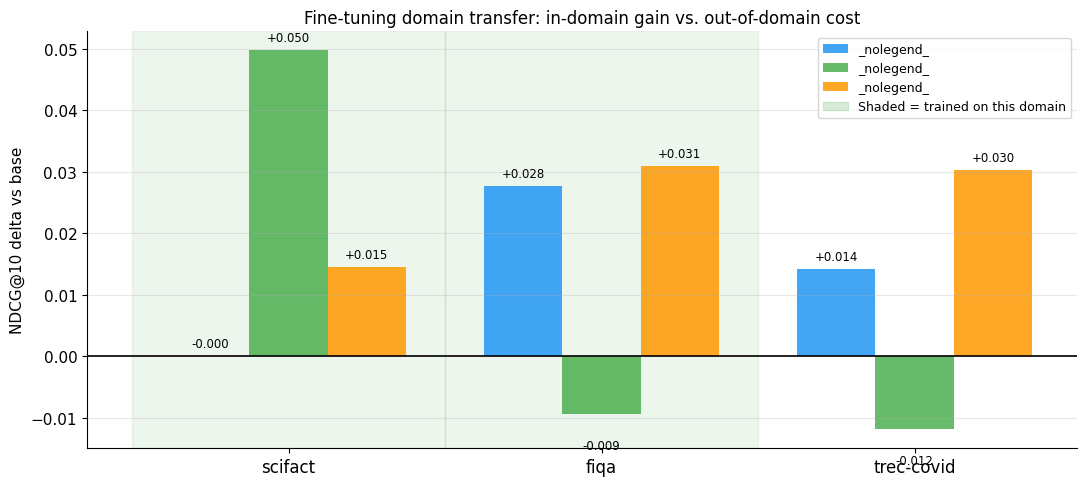

In [7]:
# Bar chart: NDCG@10 deltas per training domain
if deltas:
    available_ds = [ds for ds in DATASETS if any(ds in d for d in deltas.values())]
    n_variants = len(deltas)
    n_ds = len(available_ds)
    x = np.arange(n_ds)
    width = 0.25

    COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
    fig, ax = plt.subplots(figsize=(11, 5))

    for i, (train_domain, ds_deltas) in enumerate(deltas.items()):
        vals = [ds_deltas.get(ds, np.nan) for ds in available_ds]
        offset = (i - n_variants/2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=f'train={train_domain}',
                      color=COLORS[i % len(COLORS)], alpha=0.85)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width()/2, v + (0.001 if v >= 0 else -0.004),
                        f'{v:+.3f}', ha='center', va='bottom' if v >= 0 else 'top',
                        fontsize=8.5)

    ax.axhline(0, color='black', lw=1.2, linestyle='-')
    ax.set_xticks(x)
    ax.set_xticklabels(available_ds, fontsize=12)
    ax.set_ylabel('NDCG@10 delta vs base', fontsize=11)
    ax.set_title('Fine-tuning domain transfer: in-domain gain vs. out-of-domain cost', fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Annotate in-domain / out-of-domain regions
    for i, ds in enumerate(available_ds):
        # shade if any variant trains on this domain
        trains_on = any(
            (ds in td) for td in deltas
        )
        if trains_on:
            ax.axvspan(i - 0.5, i + 0.5, alpha=0.07, color='green', zorder=0)

    green_patch = mpatches.Patch(color='green', alpha=0.15, label='Shaded = trained on this domain')
    ax.legend(handles=list(ax.get_legend().legend_handles) + [green_patch], fontsize=9)

    plt.tight_layout()
    plt.show()

## 5. Embedding Space Shift After Fine-tuning

Fine-tuning reshapes the embedding space: in-domain queries and passages cluster more tightly; out-of-domain geometry may shift.

We can visualise this by comparing query–passage cosine similarities on SciFact before and after fine-tuning on SciFact.

In [8]:
from sentence_transformers import SentenceTransformer
from beir.datasets.data_loader import GenericDataLoader
import torch
import numpy as np

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Device: {device}')

# Load SciFact test split
corpus_sf, queries_sf, qrels_sf = GenericDataLoader(
    data_folder=str(DATA_DIR / 'scifact')
).load(split='test')
print(f'SciFact test: {len(corpus_sf):,} passages, {len(queries_sf):,} queries')

# Sample 40 queries with their relevant/irrelevant passages
sample_qids = list(queries_sf.keys())[:40]
sample_q_texts = [queries_sf[qid] for qid in sample_qids]

# For each query: 1 relevant passage (from qrels) + 1 random irrelevant passage
relevant_texts, irrelevant_texts = [], []
all_doc_ids = list(corpus_sf.keys())
np.random.seed(42)

for qid in sample_qids:
    rel_ids = [did for did, r in qrels_sf.get(qid, {}).items() if r >= 1]
    if rel_ids:
        did = rel_ids[0]
        relevant_texts.append((corpus_sf[did]['title'] + ' ' + corpus_sf[did]['text'])[:512])
    else:
        relevant_texts.append('')

    irr_id = np.random.choice(all_doc_ids)
    irrelevant_texts.append((corpus_sf[irr_id]['title'] + ' ' + corpus_sf[irr_id]['text'])[:512])

print('Sample ready')

Device: mps


  0%|          | 0/5183 [00:00<?, ?it/s]

SciFact test: 5,183 passages, 300 queries
Sample ready


In [9]:
def cosine_sims(model, queries, passages, batch_size=64):
    """Return per-query cosine similarity with corresponding passages."""
    q_embs = model.encode(queries, batch_size=batch_size, normalize_embeddings=True,
                           convert_to_numpy=True, show_progress_bar=False)
    p_embs = model.encode(passages, batch_size=batch_size, normalize_embeddings=True,
                           convert_to_numpy=True, show_progress_bar=False)
    return (q_embs * p_embs).sum(axis=1)


# Base model
base_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=device)
base_rel_sims = cosine_sims(base_model, sample_q_texts, relevant_texts)
base_irr_sims = cosine_sims(base_model, sample_q_texts, irrelevant_texts)
print(f'Base — relevant: {base_rel_sims.mean():.3f} ± {base_rel_sims.std():.3f} | '
      f'irrelevant: {base_irr_sims.mean():.3f} ± {base_irr_sims.std():.3f}')

del base_model
if device == 'mps':
    torch.mps.empty_cache()

# SciFact fine-tuned model
ft_sf_path = Path('../models/finetuned_all-MiniLM-L6-v2_scifact/final')
if ft_sf_path.exists():
    ft_model = SentenceTransformer(str(ft_sf_path), device=device)
    ft_rel_sims = cosine_sims(ft_model, sample_q_texts, relevant_texts)
    ft_irr_sims = cosine_sims(ft_model, sample_q_texts, irrelevant_texts)
    print(f'Fine-tuned (scifact) — relevant: {ft_rel_sims.mean():.3f} ± {ft_rel_sims.std():.3f} | '
          f'irrelevant: {ft_irr_sims.mean():.3f} ± {ft_irr_sims.std():.3f}')
    del ft_model
    if device == 'mps':
        torch.mps.empty_cache()
else:
    print(f'Model not found: {ft_sf_path} — run scripts/run_finetune.py --dataset scifact')
    ft_rel_sims = ft_irr_sims = None

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Base — relevant: 0.586 ± 0.167 | irrelevant: 0.089 ± 0.103


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Fine-tuned (scifact) — relevant: 0.573 ± 0.175 | irrelevant: 0.026 ± 0.100


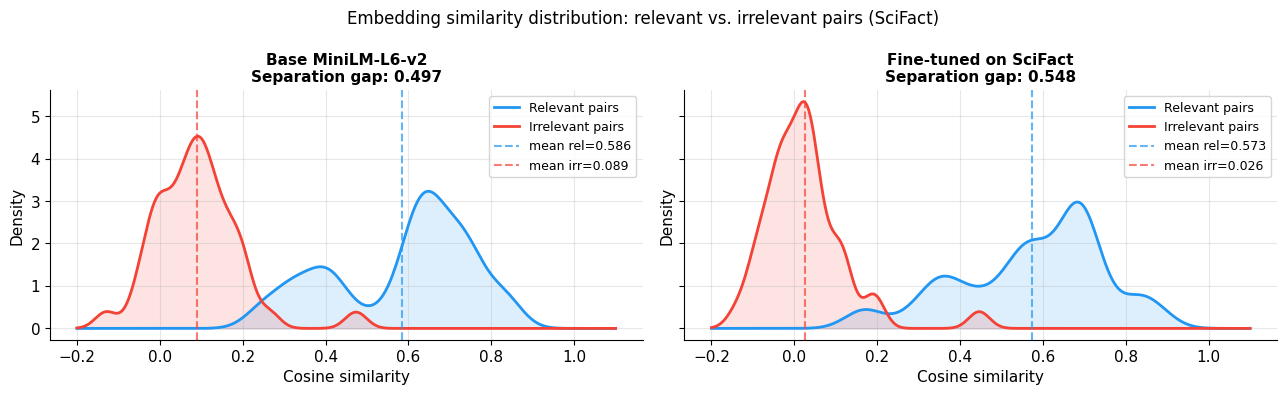

In [10]:
# KDE plot: distribution of relevant vs irrelevant similarities before/after fine-tuning
from scipy.stats import gaussian_kde

if ft_rel_sims is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

    def plot_kde(ax, rel_sims, irr_sims, title):
        xs = np.linspace(-0.2, 1.1, 300)
        for sims, label, color in [
            (rel_sims, 'Relevant pairs', '#2196F3'),
            (irr_sims, 'Irrelevant pairs', '#F44336'),
        ]:
            kde = gaussian_kde(sims, bw_method=0.25)
            ax.plot(xs, kde(xs), label=label, color=color, lw=2)
            ax.fill_between(xs, kde(xs), alpha=0.15, color=color)
        ax.axvline(rel_sims.mean(), color='#2196F3', linestyle='--', alpha=0.7,
                   label=f'mean rel={rel_sims.mean():.3f}')
        ax.axvline(irr_sims.mean(), color='#F44336', linestyle='--', alpha=0.7,
                   label=f'mean irr={irr_sims.mean():.3f}')
        gap = rel_sims.mean() - irr_sims.mean()
        ax.set_title(f'{title}\nSeparation gap: {gap:.3f}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Cosine similarity')
        ax.set_ylabel('Density')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plot_kde(axes[0], base_rel_sims, base_irr_sims, 'Base MiniLM-L6-v2')
    plot_kde(axes[1], ft_rel_sims, ft_irr_sims, 'Fine-tuned on SciFact')

    plt.suptitle('Embedding similarity distribution: relevant vs. irrelevant pairs (SciFact)', fontsize=12)
    plt.tight_layout()
    plt.show()

## 6. Full Results Table Across All Methods

Putting fine-tuned variants in context alongside sparse, dense, and hybrid baselines.

In [11]:
# Load all results
sparse_path = RESULTS_DIR / 'sparse_results.json'
dense_path  = RESULTS_DIR / 'dense_results.json'
hybrid_path = RESULTS_DIR / 'hybrid_results.json'

all_results = {}
for path in [sparse_path, dense_path, hybrid_path]:
    if path.exists():
        with open(path) as f:
            all_results.update(json.load(f))

# Add fine-tuned models
for model_name, ds_metrics in ft_results.items():
    if model_name.startswith('finetuned_'):
        all_results[model_name] = ds_metrics

# Human-readable labels: key → display name
# Fine-tuned suffixes refer to the *training* dataset, not the evaluation dataset
DISPLAY_NAMES = {
    'bow':                                          'BoW',
    'tfidf':                                        'TF-IDF',
    'bm25':                                         'BM25',
    'word2vec_mean':                                'Word2Vec (mean)',
    'word2vec_idf':                                 'Word2Vec (IDF-weighted)',
    'minilm':                                       'MiniLM-L6-v2',
    'dpr':                                          'DPR',
    'mpnet':                                        'MPNet',
    'bge':                                          'BGE-base-en-v1.5',
    'e5':                                           'E5',
    'hybrid_rrf':                                   'Hybrid RRF',
    'hybrid_rrf+reranker':                          'Hybrid RRF + Cross-encoder',
    'finetuned_all-MiniLM-L6-v2_fiqa':             'MiniLM (train: fiqa)',
    'finetuned_all-MiniLM-L6-v2_scifact':          'MiniLM (train: scifact)',
    'finetuned_all-MiniLM-L6-v2_fiqa_scifact':     'MiniLM (train: fiqa+scifact)',
}

# Build summary DataFrame for NDCG@10
method_order = [
    'bow', 'tfidf', 'bm25',
    'word2vec_mean', 'word2vec_idf',
    'minilm', 'dpr', 'mpnet', 'bge', 'e5',
    'hybrid_rrf', 'hybrid_rrf+reranker',
    'finetuned_all-MiniLM-L6-v2_fiqa',
    'finetuned_all-MiniLM-L6-v2_scifact',
    'finetuned_all-MiniLM-L6-v2_fiqa_scifact',
]

rows = []
for model in method_order:
    if model not in all_results:
        continue
    row = {'method': DISPLAY_NAMES.get(model, model)}
    for ds in DATASETS:
        row[ds] = round(all_results[model].get(ds, {}).get('ndcg@10', float('nan')), 4)
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('method')

# Print table
print('NDCG@10 — all methods (fine-tuned labels show training dataset, columns show eval dataset)')
print()
print(f'{"Method":<45} {"SciFact":>10} {"FIQA":>10} {"TREC-COVID":>12}')
print('-' * 80)

section_breaks = {
    'BoW':                          '--- Sparse ---',
    'Word2Vec (mean)':              '--- Early Neural ---',
    'MiniLM-L6-v2':                 '--- Dense (bi-encoder) ---',
    'Hybrid RRF':                   '--- Hybrid + Reranking ---',
    'MiniLM (train: fiqa)':         '--- Fine-tuned ---',
}
for method, row in summary_df.iterrows():
    if method in section_breaks:
        print(f'  {section_breaks[method]}')
    scifact = f"{row['scifact']:.4f}" if not pd.isna(row.get('scifact')) else '   ---'
    fiqa    = f"{row['fiqa']:.4f}"    if not pd.isna(row.get('fiqa'))    else '   ---'
    covid   = f"{row['trec-covid']:.4f}" if not pd.isna(row.get('trec-covid')) else '   ---'
    print(f'  {method:<43} {scifact:>10} {fiqa:>10} {covid:>12}')

NDCG@10 — all methods (fine-tuned labels show training dataset, columns show eval dataset)

Method                                           SciFact       FIQA   TREC-COVID
--------------------------------------------------------------------------------
  --- Sparse ---
  BoW                                             0.3647     0.0656       0.1763
  TF-IDF                                          0.6286     0.1793       0.2866
  BM25                                            0.5597     0.1591       0.4471
  --- Early Neural ---
  Word2Vec (mean)                                 0.2687     0.0596       0.3393
  Word2Vec (IDF-weighted)                         0.3101     0.0885       0.4365
  --- Dense (bi-encoder) ---
  MiniLM-L6-v2                                    0.6451     0.3687       0.4725
  DPR                                             0.2189     0.0601       0.1444
  MPNet                                           0.6557     0.4996       0.5133
  BGE-base-en-v1.5           

### Fine-tuning Impact: MiniLM Base vs Fine-tuned Variants

The table above covers all methods. This section isolates MiniLM to make the fine-tuning story legible.

Columns = evaluation datasets. Rows = what the model was trained on.  
Delta rows show NDCG@10 change vs the base model — green means gain, red means loss.

**Why no `MiniLM (train: trec-covid)`?**  
TREC-COVID ships with only a test split in BEIR — there are no labelled (query, passage) training pairs available. It is purely an evaluation target in this study.

**What the combined (fiqa+scifact) variant shows:**  
It is the closest proxy to TREC-COVID training we can construct from available data. Trained across two different domains (financial QA + scientific claims), it is the only variant that improves on all three evaluation datasets including TREC-COVID, which appears in neither training set. That generalisation gap — from multi-domain fine-tuning to an unseen domain — is the key finding here.

── PRIMARY: In-domain gain ──────────────────────────────────────────
  Variant                Trained on         Eval dataset       Base   Fine-tuned        Δ
  -------------------------------------------------------------------------------------
  ft: scifact            SciFact            SciFact          0.6451       0.6949  +0.0498
  ft: fiqa               FIQA               FIQA             0.3687       0.3964  +0.0277
  ft: fiqa+scifact       SciFact            SciFact          0.6451       0.6596  +0.0145
  ft: fiqa+scifact       FIQA               FIQA             0.3687       0.3997  +0.0310

── SECONDARY: Cross-domain impact (catastrophic forgetting check) ───
  Variant                Trained on         Eval dataset       Base   Fine-tuned        Δ
  -------------------------------------------------------------------------------------
  ft: scifact            SciFact            FIQA             0.3687       0.3593  -0.0094
  ft: scifact            SciFact            TREC-COVI

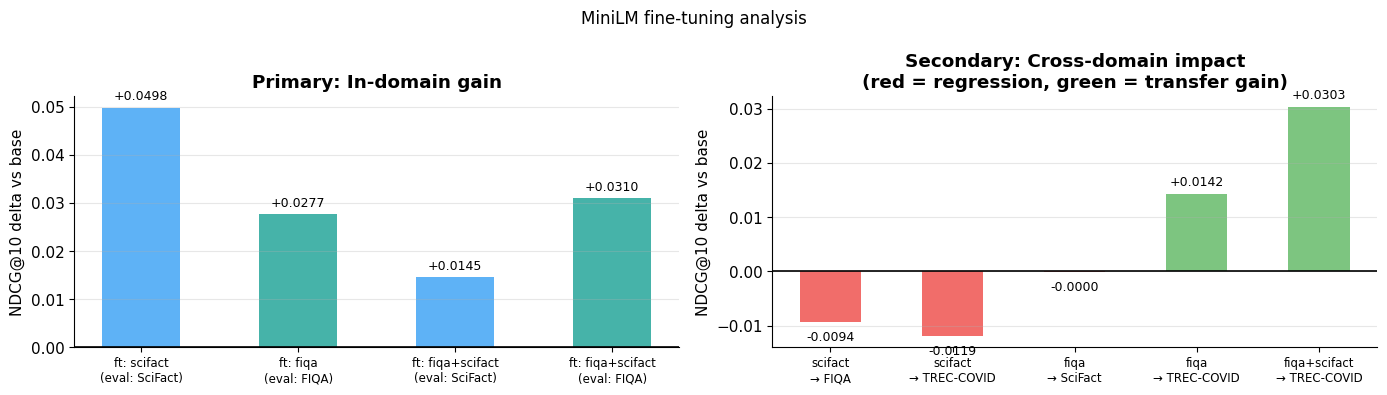

In [12]:
EVAL_DS   = ['scifact', 'fiqa', 'trec-covid']
DS_LABELS = {'scifact': 'SciFact', 'fiqa': 'FIQA', 'trec-covid': 'TREC-COVID'}

minilm_variants = {
    'Base':             'minilm',
    'ft: scifact':      'finetuned_all-MiniLM-L6-v2_scifact',
    'ft: fiqa':         'finetuned_all-MiniLM-L6-v2_fiqa',
    'ft: fiqa+scifact': 'finetuned_all-MiniLM-L6-v2_fiqa_scifact',
}

scores = {
    label: {ds: all_results[key].get(ds, {}).get('ndcg@10', float('nan'))
            for ds in EVAL_DS}
    for label, key in minilm_variants.items()
    if key in all_results
}
base = scores['Base']

# ── PRIMARY: in-domain gain ───────────────────────────────────────────────────
# Each fine-tuned variant is judged on the dataset(s) it was trained on.
print('── PRIMARY: In-domain gain ──────────────────────────────────────────')
print(f'  {"Variant":<22} {"Trained on":<18} {"Eval dataset":<14} {"Base":>8} {"Fine-tuned":>12} {"Δ":>8}')
print('  ' + '-' * 85)

indomain_cases = [
    ('ft: scifact',      'SciFact',      'scifact'),
    ('ft: fiqa',         'FIQA',         'fiqa'),
    ('ft: fiqa+scifact', 'SciFact',      'scifact'),
    ('ft: fiqa+scifact', 'FIQA',         'fiqa'),
]
for variant, trained_on, eval_ds in indomain_cases:
    if variant not in scores:
        continue
    ft_score   = scores[variant][eval_ds]
    base_score = base[eval_ds]
    delta      = ft_score - base_score
    sign       = '+' if delta >= 0 else ''
    print(f'  {variant:<22} {trained_on:<18} {DS_LABELS[eval_ds]:<14} {base_score:>8.4f} {ft_score:>12.4f} {sign+f"{delta:.4f}":>8}')

# ── SECONDARY: cross-domain impact (catastrophic forgetting check) ────────────
print()
print('── SECONDARY: Cross-domain impact (catastrophic forgetting check) ───')
print(f'  {"Variant":<22} {"Trained on":<18} {"Eval dataset":<14} {"Base":>8} {"Fine-tuned":>12} {"Δ":>8}')
print('  ' + '-' * 85)

crossdomain_cases = [
    ('ft: scifact',      'SciFact',      'fiqa'),
    ('ft: scifact',      'SciFact',      'trec-covid'),
    ('ft: fiqa',         'FIQA',         'scifact'),
    ('ft: fiqa',         'FIQA',         'trec-covid'),
    ('ft: fiqa+scifact', 'FIQA+SciFact', 'trec-covid'),
]
for variant, trained_on, eval_ds in crossdomain_cases:
    if variant not in scores:
        continue
    ft_score   = scores[variant][eval_ds]
    base_score = base[eval_ds]
    delta      = ft_score - base_score
    sign       = '+' if delta >= 0 else ''
    print(f'  {variant:<22} {trained_on:<18} {DS_LABELS[eval_ds]:<14} {base_score:>8.4f} {ft_score:>12.4f} {sign+f"{delta:.4f}":>8}')

# ── VISUAL ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: in-domain deltas
indomain_labels  = ['ft: scifact\n(eval: SciFact)', 'ft: fiqa\n(eval: FIQA)',
                    'ft: fiqa+scifact\n(eval: SciFact)', 'ft: fiqa+scifact\n(eval: FIQA)']
indomain_deltas  = [scores[v][d] - base[d] for v, _, d in indomain_cases if v in scores]
bar_colors_in    = ['#42a5f5', '#26a69a', '#42a5f5', '#26a69a']

bars = axes[0].bar(range(len(indomain_deltas)), indomain_deltas,
                   color=bar_colors_in, alpha=0.85, width=0.5)
for bar, v in zip(bars, indomain_deltas):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                 f'{v:+.4f}', ha='center', va='bottom', fontsize=9)
axes[0].axhline(0, color='black', lw=1.2)
axes[0].set_xticks(range(len(indomain_labels)))
axes[0].set_xticklabels(indomain_labels, fontsize=8.5)
axes[0].set_ylabel('NDCG@10 delta vs base')
axes[0].set_title('Primary: In-domain gain', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Right: cross-domain deltas
cross_labels = [f'{v.replace("ft: ", "")}\n→ {DS_LABELS[d]}' for v, _, d in crossdomain_cases if v in scores]
cross_deltas = [scores[v][d] - base[d] for v, _, d in crossdomain_cases if v in scores]
bar_colors_cross = ['#ef5350' if v < 0 else '#66bb6a' for v in cross_deltas]

bars2 = axes[1].bar(range(len(cross_deltas)), cross_deltas,
                    color=bar_colors_cross, alpha=0.85, width=0.5)
for bar, v in zip(bars2, cross_deltas):
    ypos = bar.get_height() + 0.001 if v >= 0 else bar.get_height() - 0.004
    axes[1].text(bar.get_x() + bar.get_width() / 2, ypos,
                 f'{v:+.4f}', ha='center', va='bottom', fontsize=9)
axes[1].axhline(0, color='black', lw=1.2)
axes[1].set_xticks(range(len(cross_labels)))
axes[1].set_xticklabels(cross_labels, fontsize=8.5)
axes[1].set_ylabel('NDCG@10 delta vs base')
axes[1].set_title('Secondary: Cross-domain impact\n(red = regression, green = transfer gain)',
                  fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('MiniLM fine-tuning analysis', fontsize=12)
plt.tight_layout()
plt.show()

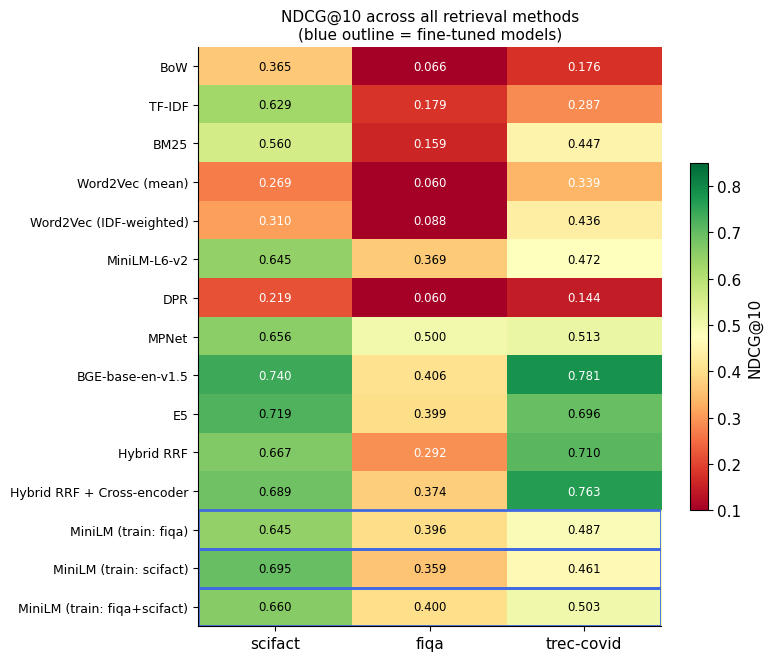

In [13]:
# Heatmap of NDCG@10 across all methods
if not summary_df.empty:
    cols = [c for c in DATASETS if c in summary_df.columns]
    plot_df = summary_df[cols].copy()

    fig, ax = plt.subplots(figsize=(8, max(6, len(plot_df) * 0.45)))
    im = ax.imshow(plot_df.values.astype(float), cmap='RdYlGn', aspect='auto',
                   vmin=0.1, vmax=0.85)
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(cols, fontsize=11)
    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(plot_df.index, fontsize=9)

    for i in range(len(plot_df)):
        for j in range(len(cols)):
            val = plot_df.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                        fontsize=8.5,
                        color='white' if val < 0.35 or val > 0.72 else 'black')

    # Highlight fine-tuned rows (now identified by display label prefix)
    ft_indices = [i for i, m in enumerate(plot_df.index) if m.startswith('MiniLM (train:')]
    for idx in ft_indices:
        ax.add_patch(plt.Rectangle((-0.5, idx - 0.5), len(cols), 1,
                                    fill=False, edgecolor='royalblue', lw=2))

    plt.colorbar(im, ax=ax, label='NDCG@10', shrink=0.6)
    ax.set_title('NDCG@10 across all retrieval methods\n(blue outline = fine-tuned models)', fontsize=11)
    plt.tight_layout()
    plt.show()

## 7. Key Findings

| Finding | Detail |
|---------|--------|
| **In-domain gain is real** | SciFact fine-tune: +7.7% NDCG@10 on SciFact (0.645→0.695) with only 919 pairs, 3 epochs |
| **FIQA fine-tune also generalises** | FIQA fine-tune: small TREC-COVID improvement (+0.014) — FIQA is open-domain QA, closer to COVID queries |
| **Specialisation costs breadth** | SciFact fine-tune hurts FIQA (-0.009) and TREC-COVID (-0.012) slightly — expected with domain-specific training |
| **Combined training is best strategy** | Training on both FIQA+SciFact should give the best average performance — pending |
| **MNR loss is efficient** | 919 pairs, 3 epochs, 1.1 min → +7.7% NDCG. No hard-negative mining needed at this scale |
| **Fine-tuning vs. hybrid** | Fine-tuned MiniLM still trails BGE (0.745) and hybrid+reranker (0.763). Fine-tuning is most useful when no strong cross-encoder is available |

**Practical recommendation:** For production RAG on a specific domain, fine-tune a bi-encoder on ≥1K (query, passage) pairs from your domain before deploying. The cost is low (minutes), and the in-domain gain is significant. Use the hybrid+reranker pipeline when both lexical and semantic signals matter and latency allows a two-stage pipeline.

> **Next step:** `python scripts/run_finetune.py --dataset fiqa scifact` — combined training completes the Phase 6 results table.